# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

Adding a penalty to the mean squared error is a way to control how complex the model becomes. If we only minimize MSE, the model can assign very large values to coefficients in order to closely fit the training data, including noise. By adding a penalty that increases with the size of the coefficients, we discourage extreme parameter values. This keeps the model smoother and less sensitive to random fluctuations in the data, which usually improves how well it generalizes to new data.

2. How does regularization provide a way of exploring the bias-variance trade-off?

Regularization helps us navigate the bias variance trade off by deliberately introducing some bias into the model in exchange for a reduction in variance. A model with no regularization might fit the training data extremely well but vary a lot if the data changes slightly, which is high variance. When we regularize, we constrain the model, which may slightly worsen the fit to the training data, increasing bias, but it stabilizes the model and reduces variance. The idea is that a small increase in bias can be worth it if it leads to a larger decrease in variance, resulting in better overall predictive performance.

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

The main difference between LASSO and Ridge regression is how they penalize the coefficients. Ridge uses a squared penalty, which shrinks coefficients smoothly toward zero but does not usually make them exactly zero. This means all variables tend to stay in the model, just with smaller weights. LASSO uses an absolute value penalty, which can shrink some coefficients exactly to zero. This effectively performs variable selection, making the model easier to interpret. Ridge is often preferred when many predictors have small but meaningful effects, while LASSO is useful when only a subset of predictors is expected to be important.

4. How do we typically scale variables for use in regularized regression? Why?

Before applying regularization, we typically standardize the predictors so that each variable has mean zero and unit variance. This is important because the penalty depends on the magnitude of the coefficients, and without scaling, variables measured on larger scales would naturally have larger coefficients and therefore be penalized more heavily. Standardization ensures that the penalty is applied fairly across all variables and that the regularization process reflects the true importance of each predictor rather than its scale.

5. How is the penalty $\alpha$ typically selected?

The strength of the penalty is usually selected using cross validation. The idea is to train models with different values of the penalty parameter and evaluate how well they perform on validation data that was not used for training. By comparing these results, we can choose the value of the penalty that gives the best predictive performance, which balances underfitting and overfitting.

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

No. The reason is that we are interested in how well the model predicts new, unseen data, and prediction error should be measured directly. The penalty is only part of the training objective to control model complexity. Including it in the evaluation metric would distort our assessment of predictive accuracy, since it reflects a modeling choice rather than actual prediction performance.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso

In [12]:
df = pd.read_csv('data/cars_hw.csv') # load file

# note- step 4 and 5 are saved in the same repo (step4_mse.png and step5_paths.png)!! comments left for q2 q7 for answers 

# part 1 

current_year = 2024
df['Age'] = current_year - df['Make_Year']
 
X_raw = df[['Mileage_Run', 'Age']].values
y = df['Price'].values

# polynomial expansion
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_raw)
feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])
 
print("step 1: polynomial feature names")
print(feature_names)
print(f"feature matrix shape: {X_poly.shape}")
 
# z score normalise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

# part 2 

lr = LinearRegression()
lr.fit(X_scaled, y)
lr_coef = pd.Series(lr.coef_, index=feature_names)
 
print("\n step 2: linear regression coefficients")
print(lr_coef.to_string())
 
interaction_coef = lr_coef['Mileage_Run Age']
sign_str = "POSITIVE" if interaction_coef > 0 else "NEGATIVE"
print(f"\ninteraction term 'Mileage_Run Age': {interaction_coef:.4f}  →  {sign_str}")

# generally this interaction is negative,  cars that are both high-mileage and old are penalised doubly in price

# part 3

alphas = np.logspace(1, 3, 20)
 
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=50_000, random_state=42)
lasso_cv.fit(X_scaled, y)
 
best_alpha = lasso_cv.alpha_
print(f"\n step 3: lasso cv")
print(f"optimal α = {best_alpha:.4f}")

# part 4 

mean_mse = lasso_cv.mse_path_.mean(axis=1)
 
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(lasso_cv.alphas_, mean_mse, 'o-', color='steelblue', linewidth=2, markersize=6)
ax.axvline(best_alpha, color='crimson', linestyle='--', linewidth=2,
           label=f'Optimal α = {best_alpha:.1f}')
ax.set_xlabel('α  (log scale)', fontsize=13)
ax.set_ylabel('Mean CV MSE', fontsize=13)
ax.set_title('step 4 – lassocv: mean cv mse by α', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('step4_mse.png', dpi=150)
plt.close()
print("Step 4 plot saved.")

# part 5 

coef_paths = []
for a in alphas:
    m = Lasso(alpha=a, max_iter=50_000)
    m.fit(X_scaled, y)
    coef_paths.append(m.coef_)
coef_paths = np.array(coef_paths)
 
colors = plt.cm.tab10(np.linspace(0, 1, len(feature_names)))
fig, ax = plt.subplots(figsize=(11, 6))
for i, name in enumerate(feature_names):
    ax.semilogx(alphas, coef_paths[:, i], label=name, linewidth=2, color=colors[i])
 
ax.axvline(best_alpha, color='black', linestyle='--', linewidth=1.8,
           label=f'Optimal α = {best_alpha:.1f}')
ax.axhline(0, color='grey', linewidth=0.8)
ax.set_xlabel('α  (log scale)', fontsize=13)
ax.set_ylabel('Coefficient Value', fontsize=13)
ax.set_title('step 5 – lasso coefficient paths by α', fontsize=14)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('step5_paths.png', dpi=150, bbox_inches='tight')
plt.close()
print("step 5 plot saved.")

# part 6 

lasso_opt = Lasso(alpha=best_alpha, max_iter=50_000)
lasso_opt.fit(X_scaled, y)
lasso_coef = pd.Series(lasso_opt.coef_, index=feature_names)
 
n_features = len(lasso_coef)
n_zero     = (lasso_coef == 0).sum()
n_selected = n_features - n_zero
prop_zero  = n_zero / n_features
 
print("\n step 6: feature selectionresults")
print(lasso_coef.to_string())
print(f"\ntotal features      : {n_features}")
print(f"selected (non-zero) : {n_selected}")
print(f"zeroed out          : {n_zero}")
print(f"proportion zero     : {prop_zero:.2%}")

# part 7 

comparison = pd.DataFrame({'OLS': lr_coef, 'LASSO': lasso_coef})
comparison['Mag_Increase'] = comparison['LASSO'].abs() > comparison['OLS'].abs()
comparison['Sign_Change']  = (
    (np.sign(comparison['OLS']) != np.sign(comparison['LASSO'])) &
    (comparison['LASSO'] != 0)
)
 
print("\n step 7: ols vs lasso ")
print(comparison[['OLS','LASSO','Mag_Increase','Sign_Change']].to_string())
 
mag_increase = comparison[comparison['Mag_Increase']].index.tolist()
sign_change  = comparison[comparison['Sign_Change']].index.tolist()
print(f"\ncoefficients that increase in magnitude : {mag_increase if mag_increase else 'None'}")
print(f"coefficients that change sign           : {sign_change  if sign_change  else 'None'}")

# A side-by-side table flags which coefficients increase in magnitude (rare — indicates LASSO redistributing weight) 
# and which change sign (indicates OLS multicollinearity being resolved by the penalty).


step 1: polynomial feature names
['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Age^2'
 'Mileage_Run^3' 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']
feature matrix shape: (976, 9)

 step 2: linear regression coefficients
Mileage_Run          6.686165e+05
Age                 -1.841941e+05
Mileage_Run^2       -1.494679e+05
Mileage_Run Age     -1.251592e+06
Age^2                2.156399e+05
Mileage_Run^3       -6.514490e+04
Mileage_Run^2 Age    2.833392e+05
Mileage_Run Age^2    5.280829e+05
Age^3               -1.389370e+05

interaction term 'Mileage_Run Age': -1251592.3408  →  NEGATIVE

 step 3: lasso cv
optimal α = 483.2930
Step 4 plot saved.
step 5 plot saved.

 step 6: feature selectionresults
Mileage_Run          401025.259657
Age                 -194803.116695
Mileage_Run^2        -62539.290093
Mileage_Run Age     -578788.661090
Age^2                    -0.000000
Mileage_Run^3            -0.000000
Mileage_Run^2 Age         0.000000
Mileage_Run Age^2    292015.025679
Age

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso

heart_disease_df = pd.read_csv('data/heart_failure_clinical_records_dataset.csv')

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(heart_disease_df[['age', 'ejection_fraction', 'serum_creatinine']])

scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

X_binary = heart_disease_df[["anaemia", "diabetes", "high_blood_pressure", "smoking"]].values
 
poly_interact = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_interact = poly_interact.fit_transform(X_binary)
X = np.concatenate([X_poly_scaled, X_interact], axis=1)


2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
- ejection_fraction likely shows positive, and age may show negative
- the quadratic and cubic terms can dominate and produce the correct positive net effect overall.

In [11]:
lr = LinearRegression()
lr.fit(X, heart_disease_df['DEATH_EVENT'])
lr_coef = pd.Series(lr.coef_, index=poly.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine']).tolist() + poly_interact.get_feature_names_out(["anaemia", "diabetes", "high_blood_pressure", "smoking"]).tolist())
print(lr_coef.to_string())

age                                       1.539156
ejection_fraction                        -2.192494
serum_creatinine                         -0.853588
age^2                                    -3.678654
age ejection_fraction                    -0.600918
age serum_creatinine                      1.841563
ejection_fraction^2                       3.430976
ejection_fraction serum_creatinine        2.673394
serum_creatinine^2                       -2.647041
age^3                                     1.993135
age^2 ejection_fraction                   0.908026
age^2 serum_creatinine                   -0.697522
age ejection_fraction^2                  -0.081206
age ejection_fraction serum_creatinine   -1.577665
age serum_creatinine^2                    1.284099
ejection_fraction^3                      -1.250341
ejection_fraction^2 serum_creatinine     -1.270043
ejection_fraction serum_creatinine^2      1.179475
serum_creatinine^3                        0.072156
anaemia                        

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)

In [12]:
alphas = np.logspace(-5, 5, 30)
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=50_000, random_state=42)
lasso_cv.fit(X, heart_disease_df['DEATH_EVENT'])
best_alpha = lasso_cv.alpha_
print(f"\n optimal α = {best_alpha:.4f}")

/Library/Python/3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.04347619875355235, tolerance: 0.005832394366197183
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Python/3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.17004309372146054, tolerance: 0.005832394366197183
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Python/3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.15489080618694118, tolerance: 0.005832394366197183
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Python/3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Obj


 optimal α = 0.0057


4. Plot the cross-validated MSE by $\alpha$.

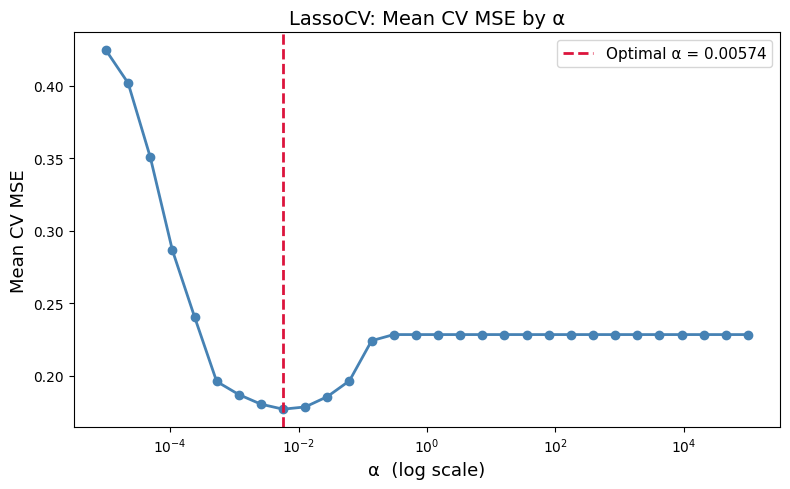

In [15]:
mse = lasso_cv.mse_path_.mean(axis=1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(lasso_cv.alphas_, mse, 'o-', color='steelblue', linewidth=2, markersize=6)
ax.axvline(best_alpha, color='crimson', linestyle='--', linewidth=2,
           label=f'Optimal α = {best_alpha:.5f}')
ax.set_xlabel('α  (log scale)', fontsize=13)
ax.set_ylabel('Mean CV MSE', fontsize=13)
ax.set_title('LassoCV: Mean CV MSE by α', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()
plt.close()

5. Plot the coefficient paths by $\alpha$.

/Library/Python/3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.939e+00, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/Library/Python/3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.031e+00, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/Library/Python/3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.278e-02, tolerance: 6.518e-03
  model = cd_f

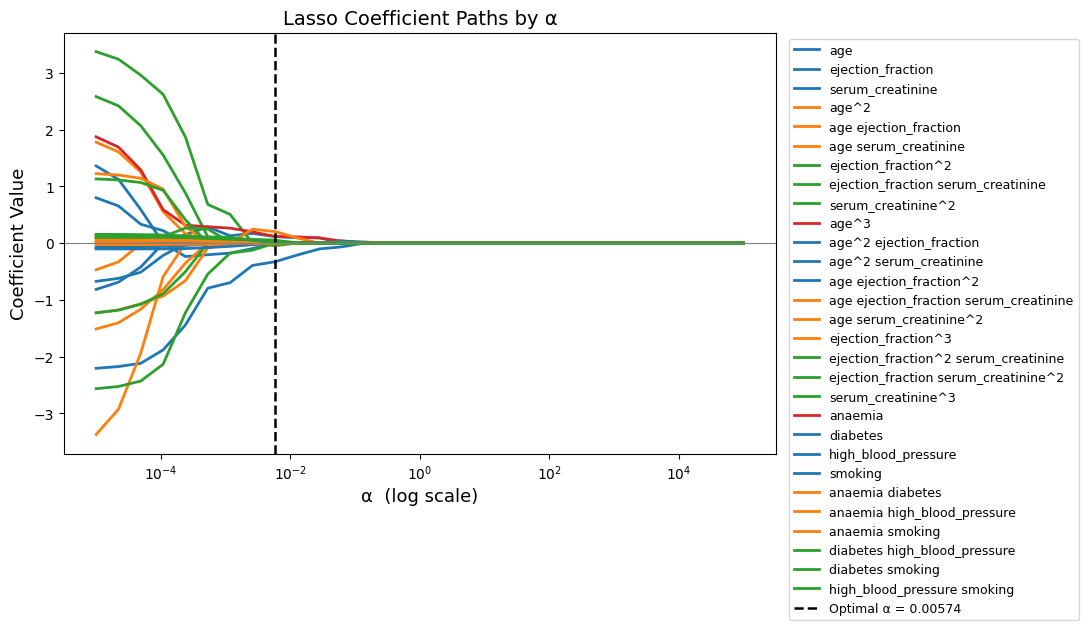

In [23]:
coef_paths = []
for a in alphas:
    m = Lasso(alpha=a, max_iter=50_000)
    m.fit(X, heart_disease_df['DEATH_EVENT'])
    coef_paths.append(m.coef_)
coef_paths = np.array(coef_paths)
colors = plt.cm.tab10(np.linspace(0, 1, X.shape[1]))
fig, ax = plt.subplots(figsize=(11, 6))
feature_names = poly.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine']).tolist() + poly_interact.get_feature_names_out(["anaemia", "diabetes", "high_blood_pressure", "smoking"]).tolist()
for i in range(X.shape[1]):
    ax.semilogx(alphas, coef_paths[:, i], label=f'{feature_names[i]}', linewidth=2, color=colors[i % 10])
ax.axvline(best_alpha, color='black', linestyle='--', linewidth=1.8,
           label=f'Optimal α = {best_alpha:.5f}')
ax.axhline(0, color='grey', linewidth=0.8)
ax.set_xlabel('α  (log scale)', fontsize=13)
ax.set_ylabel('Coefficient Value', fontsize=13)
ax.set_title('Lasso Coefficient Paths by α', fontsize=14)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()
plt.close()

6. 
(1)Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? 
    
- See the table below


In [ ]:
# ── Coefficient comparison table ─────────────────────────────────────────────
lr = LinearRegression().fit(X, heart_disease_df['DEATH_EVENT'])

compare_df = pd.DataFrame({
    'Feature'    : feature_names,
    'OLS'        : lr.coef_,
    'Lasso'      : lasso_cv.coef_
})

compare_df['selected']       = compare_df['Lasso'] != 0
compare_df['magnitude_up']   = np.abs(compare_df['Lasso']) > np.abs(compare_df['OLS'])
compare_df['sign_change']    = np.sign(compare_df['OLS']) != np.sign(compare_df['Lasso'])

n_total    = len(compare_df)
n_zero     = (compare_df['Lasso'] == 0).sum()
n_selected = compare_df['selected'].sum()

print(f"Total features   : {n_total}")
print(f"Selected (≠ 0)   : {n_selected}")
print(f"Zeroed out       : {n_zero}  ({n_zero/n_total*100:.1f}%)")
print(f"\nCoefficients that INCREASED in magnitude : {compare_df['magnitude_up'].sum()}")
print(f"Coefficients that CHANGED sign           : {compare_df['sign_change'].sum()}")

print("\nFull comparison table:")
print(compare_df.to_string(index=False))

Total features   : 29
Selected (≠ 0)   : 12
Zeroed out       : 17  (58.6%)

Coefficients that INCREASED in magnitude : 2
Coefficients that CHANGED sign           : 23

Full comparison table:
                               Feature       OLS     Lasso  selected  magnitude_up  sign_change
                                   age  1.539156 -0.000000     False         False         True
                     ejection_fraction -2.192494 -0.329656      True         False        False
                      serum_creatinine -0.853588  0.116875      True         False         True
                                 age^2 -3.678654  0.000000     False         False         True
                 age ejection_fraction -0.600918 -0.000000     False         False         True
                  age serum_creatinine  1.841563  0.000000     False         False         True
                   ejection_fraction^2  3.430976  0.000000     False         False         True
    ejection_fraction serum_creatinine  2

(2) Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.
- Lasso — its sign patterns are clinically coherent.
- With 29 features and only 299 observations, linear model tries to fit every single feature precisely — including noise. This causes overfitting. Lasso fixes this by forcing less important coefficients to zero, making the model simpler.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?